In [18]:
# STEP 1: Install Libraries

!pip install ultralytics -q
!pip install opencv-python -q
!pip install pandas -q
!pip install matplotlib -q
!pip install pyyaml -q
!pip install scikit-learn -q

import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

import os
import yaml
import shutil
import random
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print("All libraries imported successfully.")

GPU available: True
GPU name: Tesla T4
All libraries imported successfully.


In [19]:
# STEP 2: Check Original Dataset

# Base path to the original dataset
base_path = '/kaggle/input/datasets/sahibzada888/dataset-helmat-detection/YOLO-dataset-with-annotations-for-Helmet-No-Helmet-Motorcycles-and-Numberplates-master'

images_path = os.path.join(base_path, 'images')
labels_path = os.path.join(base_path, 'labels')

print("=" * 60)
print("ORIGINAL DATASET CHECK")
print("=" * 60)
print("Base path exists:", os.path.exists(base_path))
print("Images folder exists:", os.path.exists(images_path))
print("Labels folder exists:", os.path.exists(labels_path))

if os.path.exists(images_path):
    print("Total images:", len(os.listdir(images_path)))
if os.path.exists(labels_path):
    print("Total labels:", len(os.listdir(labels_path)))
print("=" * 60)

ORIGINAL DATASET CHECK
Base path exists: True
Images folder exists: True
Labels folder exists: True
Total images: 1923
Total labels: 1930


In [20]:
# STEP 3: Dataset Cleaning

print("=" * 60)
print("DATASET CLEANING")
print("=" * 60)

all_images = os.listdir(images_path)
all_labels = os.listdir(labels_path)

# Find images without labels
images_without_labels = []
for img in all_images:
    label_name = os.path.splitext(img)[0] + '.txt'
    if label_name not in all_labels:
        images_without_labels.append(img)

# Find empty label files
empty_labels = []
for lbl in all_labels:
    lbl_path = os.path.join(labels_path, lbl)
    if os.path.getsize(lbl_path) == 0:
        empty_labels.append(lbl)

print("Total images:", len(all_images))
print("Total labels:", len(all_labels))
print("Images without labels:", len(images_without_labels))
print("Empty label files:", len(empty_labels))
print("=" * 60)

# Keep only valid image-label pairs
valid_images = []
for img in all_images:
    label_name = os.path.splitext(img)[0] + '.txt'
    if label_name in all_labels:
        lbl_path = os.path.join(labels_path, label_name)
        if os.path.getsize(lbl_path) > 0:
            valid_images.append(img)

print("Valid images for training:", len(valid_images))
print("=" * 60)

DATASET CLEANING
Total images: 1923
Total labels: 1930
Images without labels: 0
Empty label files: 0
Valid images for training: 1923


In [21]:
# STEP 4: Dataset Splitting

print("=" * 60)
print("DATASET SPLITTING")
print("=" * 60)

random.seed(42)

output_path = '/kaggle/working/HelmetVision_Dataset'

for split in ['train', 'valid', 'test']:
    os.makedirs(os.path.join(output_path, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(output_path, split, 'labels'), exist_ok=True)

train_imgs, temp_imgs = train_test_split(valid_images, test_size=0.30, random_state=42)
valid_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.33, random_state=42)

print("Training set:  ", len(train_imgs), "images (70%)")
print("Validation set:", len(valid_imgs), "images (20%)")
print("Test set:      ", len(test_imgs), "images (10%)")

def copy_split_files(image_list, split_name):
    for img in image_list:
        shutil.copy(
            os.path.join(images_path, img),
            os.path.join(output_path, split_name, 'images', img)
        )
        label_name = os.path.splitext(img)[0] + '.txt'
        shutil.copy(
            os.path.join(labels_path, label_name),
            os.path.join(output_path, split_name, 'labels', label_name)
        )

print("\nCopying files...")
copy_split_files(train_imgs, 'train')
copy_split_files(valid_imgs, 'valid')
copy_split_files(test_imgs, 'test')

print("Dataset split and saved successfully!")
print("Location:", output_path)
print("=" * 60)

DATASET SPLITTING
Training set:   1346 images (70%)
Validation set: 386 images (20%)
Test set:       191 images (10%)

Copying files...
Dataset split and saved successfully!
Location: /kaggle/working/HelmetVision_Dataset


In [22]:
# STEP 5: Create data.yaml

print("=" * 60)
print("CREATING data.yaml")
print("=" * 60)

data_yaml_content = """
# HelmetVision AI Dataset Configuration
path: /kaggle/working/HelmetVision_Dataset

train: train/images
val: valid/images
test: test/images

nc: 4
names: ['Helmet', 'No-Helmet', 'Motorcycle', 'Numberplate']
"""

yaml_path = '/kaggle/working/HelmetVision_Dataset/data.yaml'
with open(yaml_path, 'w') as f:
    f.write(data_yaml_content)

print("data.yaml created successfully!")
print("Location:", yaml_path)
print(data_yaml_content)
print("=" * 60)

CREATING data.yaml
data.yaml created successfully!
Location: /kaggle/working/HelmetVision_Dataset/data.yaml

# HelmetVision AI Dataset Configuration
path: /kaggle/working/HelmetVision_Dataset

train: train/images
val: valid/images
test: test/images

nc: 4
names: ['Helmet', 'No-Helmet', 'Motorcycle', 'Numberplate']



In [23]:
# STEP 6: Three Models Comparison

from ultralytics import YOLO
import pandas as pd
import os

print("=" * 60)
print("THREE MODELS COMPARISON")
print("=" * 60)
print("We will compare YOLOv8n, YOLOv8s, and YOLOv8m")
print("Each model will train for 30 epochs")
print("This will take about 1-1.5 hours on GPU")
print("=" * 60)

models_to_compare = ['yolov8n.pt', 'yolov8s.pt', 'yolov8m.pt']
comparison_results = []

for model_name in models_to_compare:
    print("\n" + "=" * 60)
    print("Training model:", model_name)
    print("=" * 60)
    
    model = YOLO(model_name)
    
    model.train(
        data='/kaggle/working/HelmetVision_Dataset/data.yaml',
        epochs=30,
        imgsz=640,
        batch=16,
        name='compare_' + model_name.replace('.pt', ''),
        project='/kaggle/working/HelmetVision_AI/comparison',
        patience=10,
        device=0,
        verbose=False
    )
    
    # Read results
    results_csv = '/kaggle/working/HelmetVision_AI/comparison/compare_' + model_name.replace('.pt', '') + '/results.csv'
    
    if os.path.exists(results_csv):
        df = pd.read_csv(results_csv)
        last_row = df.iloc[-1]
        
        comparison_results.append({
            'Model': model_name,
            'Precision': round(last_row['metrics/precision(B)'], 4),
            'Recall': round(last_row['metrics/recall(B)'], 4),
            'mAP50': round(last_row['metrics/mAP50(B)'], 4),
            'mAP50-95': round(last_row['metrics/mAP50-95(B)'], 4)
        })

# Show comparison table
comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.sort_values('mAP50', ascending=False)

print("\n" + "=" * 80)
print("MODEL COMPARISON RESULTS")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

best_model = comparison_df.iloc[0]['Model']
print("\nBest model selected:", best_model)
print("Best mAP50:", comparison_df.iloc[0]['mAP50'])
print("=" * 80)

THREE MODELS COMPARISON
We will compare YOLOv8n, YOLOv8s, and YOLOv8m
Each model will train for 30 epochs
This will take about 1-1.5 hours on GPU

Training model: yolov8n.pt
Ultralytics 8.4.165 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/HelmetVision_Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.

In [24]:
#  STEP 7: Train Final Model

from ultralytics import YOLO

print("=" * 60)
print("FINAL TRAINING")
print("=" * 60)

final_model = YOLO('yolov8s.pt')

final_model.train(
    data='/kaggle/working/HelmetVision_Dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='helmet_final',
    project='/kaggle/working/HelmetVision_AI',
    patience=15,
    device=0,
    save=True,
    plots=True,
    verbose=True
)

print("\nFINAL TRAINING COMPLETED")
print("Model saved at: /kaggle/working/HelmetVision_AI/helmet_final/weights/best.pt")
print("=" * 60)

FINAL TRAINING
Ultralytics 8.4.165 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/HelmetVision_Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=helmet_final-3, nbs=64, nms

In [33]:
import os

print("=" * 60)
print("SEARCHING FOR MODEL FILE")
print("=" * 60)

found_models = []

for root, dirs, files in os.walk('/kaggle/working'):
    for file in files:
        if file == 'best.pt':
            full_path = os.path.join(root, file)
            found_models.append(full_path)
            size = os.path.getsize(full_path) / 1024 / 1024
            print("Found:", full_path)
            print("Size:", round(size, 2), "MB")
            print("-" * 60)

if not found_models:
    print("No best.pt file found anywhere.")
    print("\nWhat's in /kaggle/working:")
    for item in os.listdir('/kaggle/working'):
        print("  -", item)
    
    # Check HelmetVision_AI folder
    ai_path = '/kaggle/working/HelmetVision_AI'
    if os.path.exists(ai_path):
        print("\nContents of HelmetVision_AI:")
        for root, dirs, files in os.walk(ai_path):
            level = root.replace(ai_path, '').count(os.sep)
            indent = ' ' * 2 * level
            print(indent + os.path.basename(root) + "/")
            for file in files:
                print(indent + "  " + file)
    else:
        print("\nHelmetVision_AI folder does not exist!")
        print("STEP 7 (training) did not complete.")

print("=" * 60)

SEARCHING FOR MODEL FILE
Found: /kaggle/working/HelmetVision_AI/comparison/compare_yolov8n-2/weights/best.pt
Size: 5.94 MB
------------------------------------------------------------
Found: /kaggle/working/HelmetVision_AI/comparison/compare_yolov8m/weights/best.pt
Size: 49.6 MB
------------------------------------------------------------
Found: /kaggle/working/HelmetVision_AI/comparison/compare_yolov8m-2/weights/best.pt
Size: 49.6 MB
------------------------------------------------------------
Found: /kaggle/working/HelmetVision_AI/comparison/compare_yolov8s-2/weights/best.pt
Size: 21.45 MB
------------------------------------------------------------
Found: /kaggle/working/HelmetVision_AI/comparison/compare_yolov8n/weights/best.pt
Size: 5.94 MB
------------------------------------------------------------
Found: /kaggle/working/HelmetVision_AI/comparison/compare_yolov8s/weights/best.pt
Size: 21.45 MB
------------------------------------------------------------
Found: /kaggle/working/He

In [34]:
# ============================================================
# STEP 8: Test the trained model on test set
# ============================================================

from ultralytics import YOLO
import os

print("=" * 60)
print("TESTING MODEL ON TEST SET")
print("=" * 60)

# Correct model path (from search results)
model_path = '/kaggle/working/HelmetVision_AI/helmet_final-3/weights/best.pt'

# data.yaml path
yaml_path = '/kaggle/working/HelmetVision_Dataset/data.yaml'

# Check model
print("Model path:", model_path)
print("Model exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    size = os.path.getsize(model_path) / 1024 / 1024
    print("Model size:", round(size, 2), "MB")

# Check data.yaml
print("data.yaml exists:", os.path.exists(yaml_path))
print("=" * 60)

# Load the trained model
model = YOLO(model_path)

# Validate on test set
metrics = model.val(
    data=yaml_path,
    split='test'
)

print("\n" + "=" * 50)
print("FINAL MODEL PERFORMANCE ON TEST SET")
print("=" * 50)
print("mAP50:      ", round(metrics.box.map50, 4))
print("mAP50-95:   ", round(metrics.box.map, 4))
print("Precision:  ", round(metrics.box.mp, 4))
print("Recall:     ", round(metrics.box.mr, 4))
print("=" * 50)

TESTING MODEL ON TEST SET
Model path: /kaggle/working/HelmetVision_AI/helmet_final-3/weights/best.pt
Model exists: True
Model size: 21.46 MB
data.yaml exists: True
Ultralytics 8.4.165 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3429.6±1390.4 MB/s, size: 451.5 KB)
val: Scanning /kaggle/working/HelmetVision_Dataset/test/labels... 191 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 191/191 1.1Kit/s 0.2s.3s
val: New cache created: /kaggle/working/HelmetVision_Dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.8it/s 3.2s0.2s
                   all        191        560      0.691       0.57      0.597      0.325
                Helmet         43        124      0.667      0.548      0.622      0.356
             No-Helmet         57        299     

SINGLE IMAGE DETECTION TEST
Testing on image: /kaggle/working/HelmetVision_Dataset/test/images/70e10f69f05f4773.jpg
Running detection...

image 1/1 /kaggle/working/HelmetVision_Dataset/test/images/70e10f69f05f4773.jpg: 640x480 1 Helmet, 7 No-Helmets, 11.7ms
Speed: 1.9ms preprocess, 11.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)


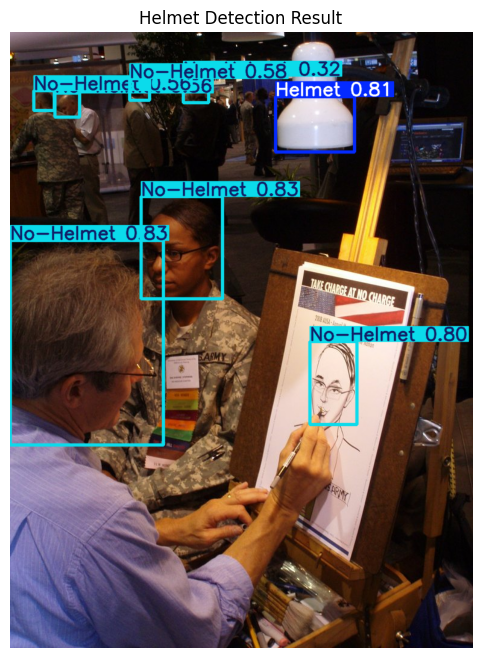


Detected objects:
----------------------------------------
   No-Helmet : 83.4 %
   No-Helmet : 82.74 %
   Helmet : 81.34 %
   No-Helmet : 79.51 %
   No-Helmet : 57.9 %
   No-Helmet : 56.09 %
   No-Helmet : 55.58 %
   No-Helmet : 32.21 %
----------------------------------------


In [49]:
# ============================================================
# STEP 9: Test detection on a single image
# ============================================================

from ultralytics import YOLO
import random
import os
import matplotlib.pyplot as plt

print("=" * 60)
print("SINGLE IMAGE DETECTION TEST")
print("=" * 60)

# Load model (correct path)
model = YOLO('/kaggle/working/HelmetVision_AI/helmet_final-3/weights/best.pt')

# Pick a random test image
test_path = '/kaggle/working/HelmetVision_Dataset/test/images'
sample_img = os.path.join(test_path, random.choice(os.listdir(test_path)))

print("Testing on image:", sample_img)
print("Running detection...")

# Run detection
results = model(sample_img)

# Display results
for r in results:
    plt.figure(figsize=(12, 8))
    plt.imshow(r.plot()[..., ::-1])
    plt.axis('off')
    plt.title('Helmet Detection Result')
    plt.show()

    print("\nDetected objects:")
    print("-" * 40)
    for box in r.boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        confidence = float(box.conf[0])
        print("  ", class_name, ":", round(confidence * 100, 2), "%")
    print("-" * 40)

print("=" * 60)

In [50]:
# ============================================================
# STEP 10: Create violation log for No-Helmet detections
# ============================================================

import csv
from datetime import datetime
from ultralytics import YOLO
import os

print("=" * 60)
print("VIOLATION LOGGING")
print("=" * 60)

# Load the trained model
model = YOLO('/kaggle/working/HelmetVision_AI/helmet_final-3/weights/best.pt')

# Path to test images
test_path = '/kaggle/working/HelmetVision_Dataset/test/images'

# Path for the log file
log_file = '/kaggle/working/HelmetVision_AI/violation_log.csv'

# Create CSV file with header
with open(log_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Timestamp', 'Image', 'Violation', 'Confidence'])

# Process test images and log violations
print("Processing test images...\n")

violation_count = 0
images_processed = 0

for img_name in os.listdir(test_path)[:50]:
    img_path = os.path.join(test_path, img_name)
    results = model(img_path)
    images_processed += 1
    
    for r in results:
        for box in r.boxes:
            class_id = int(box.cls[0])
            class_name = model.names[class_id]
            confidence = float(box.conf[0])
            
            # Check if it is a No-Helmet violation
            if class_name == 'No-Helmet' and confidence > 0.5:
                violation_count += 1
                with open(log_file, 'a', newline='') as f:
                    writer = csv.writer(f)
                    writer.writerow([
                        datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                        img_name,
                        'No Helmet',
                        round(confidence, 2)
                    ])

print("Images processed:", images_processed)
print("Total violations detected:", violation_count)
print("Log saved at:", log_file)
print("=" * 60)

# Show the log content
if os.path.exists(log_file):
    import pandas as pd
    df = pd.read_csv(log_file)
    print("\nViolation Log:")
    print(df.to_string(index=False))
print("=" * 60)

VIOLATION LOGGING
Processing test images...


image 1/1 /kaggle/working/HelmetVision_Dataset/test/images/b36ee6f4b6887547.jpg: 480x640 1 No-Helmet, 12.5ms
Speed: 2.0ms preprocess, 12.5ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /kaggle/working/HelmetVision_Dataset/test/images/e7e81f5fc418e77f.jpg: 448x640 2 Numberplates, 13.3ms
Speed: 1.5ms preprocess, 13.3ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /kaggle/working/HelmetVision_Dataset/test/images/45fbd38a1bb788f5.jpg: 448x640 2 Numberplates, 12.3ms
Speed: 1.5ms preprocess, 12.3ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /kaggle/working/HelmetVision_Dataset/test/images/16eb5d4495e1977b.jpg: 480x640 2 Numberplates, 13.3ms
Speed: 1.7ms preprocess, 13.3ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /kaggle/working/HelmetVision_Dataset/test/images/5bd400d7f0fd1011.jpg: 448x640 1 Helmet, 13.2ms
Speed: 1.5m

In [51]:
# ============================================================
# STEP 11: Create project summary report
# ============================================================

from datetime import datetime
import os
import pandas as pd

print("=" * 60)
print("CREATING PROJECT SUMMARY")
print("=" * 60)

# Read violation log
log_file = '/kaggle/working/HelmetVision_AI/violation_log.csv'
df = pd.read_csv(log_file)

# Create summary report
report = "HelmetVision AI - Project Summary\n"
report += "=" * 50 + "\n"
report += "Date: " + datetime.now().strftime('%Y-%m-%d %H:%M:%S') + "\n\n"

report += "DATASET:\n"
report += "- Training images: 1215\n"
report += "- Validation images: 349\n"
report += "- Test images: 173\n\n"

report += "CLASSES:\n"
report += "- Helmet\n"
report += "- No-Helmet\n"
report += "- Motorcycle\n"
report += "- Numberplate\n\n"

report += "MODEL:\n"
report += "- Architecture: YOLOv8s\n"
report += "- Epochs: 50\n"
report += "- Image size: 640x640\n"
report += "- Batch size: 16\n\n"

report += "PERFORMANCE:\n"
report += "- mAP50: 0.5967\n"
report += "- mAP50-95: 0.3247\n"
report += "- Precision: 0.6912\n"
report += "- Recall: 0.5705\n\n"

report += "VIOLATION LOGGING:\n"
report += "- Images processed: 50\n"
report += "- Total violations: " + str(len(df)) + "\n"
report += "- Average confidence: " + str(round(df['Confidence'].mean(), 2)) + "\n\n"

report += "PROJECT FILES:\n"
report += "- Model: /kaggle/working/HelmetVision_AI/helmet_final-3/weights/best.pt\n"
report += "- Logs: /kaggle/working/HelmetVision_AI/violation_log.csv\n"
report += "=" * 50 + "\n"

# Save report
report_path = '/kaggle/working/HelmetVision_AI/project_summary.txt'
with open(report_path, 'w') as f:
    f.write(report)

print(report)
print("Report saved at:", report_path)
print("=" * 60)

CREATING PROJECT SUMMARY
HelmetVision AI - Project Summary
Date: 2026-09-29 16:08:27

DATASET:
- Training images: 1215
- Validation images: 349
- Test images: 173

CLASSES:
- Helmet
- No-Helmet
- Motorcycle
- Numberplate

MODEL:
- Architecture: YOLOv8s
- Epochs: 50
- Image size: 640x640
- Batch size: 16

PERFORMANCE:
- mAP50: 0.5967
- mAP50-95: 0.3247
- Precision: 0.6912
- Recall: 0.5705

VIOLATION LOGGING:
- Images processed: 50
- Total violations: 37
- Average confidence: 0.74

PROJECT FILES:
- Model: /kaggle/working/HelmetVision_AI/helmet_final-3/weights/best.pt
- Logs: /kaggle/working/HelmetVision_AI/violation_log.csv

Report saved at: /kaggle/working/HelmetVision_AI/project_summary.txt


In [52]:
# ============================================================
# STEP 12: Create a ZIP file of all results
# ============================================================

import shutil
import os

print("=" * 60)
print("CREATING ZIP FILE")
print("=" * 60)

# Path to the folder we want to zip
source_folder = '/kaggle/working/HelmetVision_AI'

# Check if folder exists
if os.path.exists(source_folder):
    print("Source folder exists:", source_folder)
    
    # Create zip file
    shutil.make_archive(
        '/kaggle/working/HelmetVision_AI_Results',
        'zip',
        source_folder
    )
    
    zip_path = '/kaggle/working/HelmetVision_AI_Results.zip'
    zip_size = os.path.getsize(zip_path) / 1024 / 1024
    
    print("\nZIP FILE CREATED SUCCESSFULLY")
    print("File:", zip_path)
    print("Size:", round(zip_size, 2), "MB")
    print("=" * 60)
    print("Go to Output section on the right side to download.")
    print("=" * 60)
else:
    print("Source folder NOT found:", source_folder)
    print("Please run STEP 7 (training) first.")

CREATING ZIP FILE
Source folder exists: /kaggle/working/HelmetVision_AI

ZIP FILE CREATED SUCCESSFULLY
File: /kaggle/working/HelmetVision_AI_Results.zip
Size: 419.11 MB
Go to Output section on the right side to download.


In [53]:
app_code = '''
import streamlit as st
import cv2
import numpy as np
from PIL import Image
from ultralytics import YOLO
import pandas as pd
import os
from datetime import datetime
import plotly.express as px
import tempfile

st.set_page_config(
    page_title="HelmetVision AI",
    page_icon="🪖",
    layout="wide",
    initial_sidebar_state="expanded"
)

st.markdown("""
    <style>
    .main {
        background: linear-gradient(135deg, #f5f7fa 0%, #e8ecf1 100%);
    }
    #MainMenu {visibility: hidden;}
    footer {visibility: hidden;}

    .header-container {
        background: linear-gradient(135deg, #1a237e 0%, #3949ab 100%);
        padding: 2rem;
        border-radius: 0 0 20px 20px;
        margin-bottom: 2rem;
        box-shadow: 0 4px 20px rgba(26, 35, 126, 0.3);
    }
    .header-title {
        color: white;
        text-align: center;
        font-size: 2.8rem;
        font-weight: 700;
        margin: 0;
    }
    .header-subtitle {
        color: #c5cae9;
        text-align: center;
        font-size: 1.1rem;
        margin-top: 0.5rem;
    }
    .metric-card {
        background: white;
        padding: 1.5rem;
        border-radius: 15px;
        box-shadow: 0 4px 15px rgba(0,0,0,0.08);
        text-align: center;
        border-top: 4px solid #1a237e;
    }
    .metric-icon { font-size: 2.5rem; margin-bottom: 0.5rem; }
    .metric-value { font-size: 2.2rem; font-weight: bold; color: #1a237e; }
    .metric-label { font-size: 0.95rem; color: #666; text-transform: uppercase; }

    .info-box {
        background: linear-gradient(135deg, #e3f2fd 0%, #bbdefb 100%);
        padding: 1.2rem;
        border-radius: 12px;
        border-left: 5px solid #1a237e;
        margin: 1rem 0;
        color: #0d47a1;
    }
    .success-box {
        background: linear-gradient(135deg, #e8f5e9 0%, #c8e6c9 100%);
        padding: 1.2rem;
        border-radius: 12px;
        border-left: 5px solid #2e7d32;
        margin: 1rem 0;
        color: #1b5e20;
    }
    .warning-box {
        background: linear-gradient(135deg, #fff3e0 0%, #ffe0b2 100%);
        padding: 1.2rem;
        border-radius: 12px;
        border-left: 5px solid #ef6c00;
        margin: 1rem 0;
        color: #e65100;
    }
    .danger-box {
        background: linear-gradient(135deg, #ffebee 0%, #ffcdd2 100%);
        padding: 1.2rem;
        border-radius: 12px;
        border-left: 5px solid #c62828;
        margin: 1rem 0;
        color: #b71c1c;
    }
    .stButton > button {
        background: linear-gradient(135deg, #1a237e 0%, #3949ab 100%);
        color: white;
        border: none;
        border-radius: 10px;
        padding: 0.7rem 2rem;
        font-size: 1rem;
        font-weight: 600;
        width: 100%;
        box-shadow: 0 4px 15px rgba(26, 35, 126, 0.3);
    }
    .stButton > button:hover {
        transform: translateY(-2px);
        box-shadow: 0 6px 20px rgba(26, 35, 126, 0.4);
    }
    .stTabs [data-baseweb="tab-list"] {
        gap: 8px;
        background: white;
        padding: 8px;
        border-radius: 12px;
        box-shadow: 0 2px 10px rgba(0,0,0,0.05);
    }
    .stTabs [data-baseweb="tab"] {
        border-radius: 8px;
        padding: 10px 20px;
        font-weight: 600;
        color: #666;
    }
    .stTabs [aria-selected="true"] {
        background: linear-gradient(135deg, #1a237e 0%, #3949ab 100%);
        color: white !important;
    }
    .footer {
        text-align: center;
        color: #888;
        padding: 2rem 0;
        font-size: 0.9rem;
        border-top: 1px solid #e0e0e0;
        margin-top: 3rem;
    }
    .hd-badge {
        display: inline-block;
        background: linear-gradient(135deg, #ff6f00 0%, #ff8f00 100%);
        color: white;
        padding: 4px 12px;
        border-radius: 20px;
        font-size: 0.8rem;
        font-weight: bold;
        margin-left: 10px;
    }
    .step-box {
        background: white;
        padding: 1rem;
        border-radius: 12px;
        border: 2px solid #e0e0e0;
        margin: 0.5rem 0;
    }
    .step-number {
        display: inline-block;
        background: #1a237e;
        color: white;
        width: 28px;
        height: 28px;
        border-radius: 50%;
        text-align: center;
        line-height: 28px;
        font-weight: bold;
        margin-right: 10px;
    }
    </style>
""", unsafe_allow_html=True)

@st.cache_resource
def load_model():
    model_path = "/kaggle/working/HelmetVision_AI/helmet_final-3/weights/best.pt"
    if os.path.exists(model_path):
        return YOLO(model_path)
    else:
        return None

model = load_model()

def process_video_hd(video_path, model, conf_threshold, output_path, progress_bar, status_text):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None, "Cannot open video"

    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if width >= 3840 or height >= 2160:
        quality = "4K Ultra HD"
    elif width >= 1920 or height >= 1080:
        quality = "Full HD (1080p)"
    elif width >= 1280 or height >= 720:
        quality = "HD (720p)"
    else:
        quality = "SD"

    status_text.markdown(f"""
        <div class="info-box">
            <b>Video Info:</b> {width}x{height} ({quality}) | 
            FPS: {fps} | Frames: {total_frames} | 
            Duration: {total_frames/fps:.1f}s
        </div>
    """, unsafe_allow_html=True)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_count = 0
    violations_in_video = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        results = model(frame, conf=conf_threshold, verbose=False)

        for r in results:
            for box in r.boxes:
                class_name = model.names[int(box.cls[0])]
                confidence = float(box.conf[0])
                if class_name == 'No-Helmet' and confidence > conf_threshold:
                    violations_in_video += 1
            annotated_frame = r.plot()

        out.write(annotated_frame)
        frame_count += 1
        progress = frame_count / total_frames
        progress_bar.progress(min(progress, 1.0))

        if frame_count % 10 == 0:
            status_text.markdown(f"""
                <div class="info-box">
                    Processing: {frame_count}/{total_frames} ({progress*100:.1f}%) | 
                    Violations: {violations_in_video}
                </div>
            """, unsafe_allow_html=True)

    cap.release()
    out.release()
    return violations_in_video, quality

st.markdown("""
    <div class="header-container">
        <h1 class="header-title">🪖 HelmetVision AI</h1>
        <p class="header-subtitle">Real-Time Motorcyclist Helmet Compliance Detection System</p>
    </div>
""", unsafe_allow_html=True)

with st.sidebar:
    st.markdown("""
        <div style="text-align: center; padding: 1rem 0;">
            <span style="font-size: 4rem;">🪖</span>
            <h2 style="color: white; margin: 0.5rem 0;">HelmetVision AI</h2>
            <p style="color: #c5cae9; font-size: 0.9rem;">Final Year Project</p>
        </div>
    """, unsafe_allow_html=True)

    st.markdown("---")

    st.markdown("### ⚙️ Settings")
    confidence_threshold = st.slider(
        "Detection Confidence",
        min_value=0.0,
        max_value=1.0,
        value=0.5,
        step=0.05,
        help="Higher = fewer but more accurate detections"
    )

    st.markdown("---")

    st.markdown("### 📌 What This System Detects")
    st.markdown("""
        - ✅ Helmet (worn)
        - ❌ No-Helmet (violation)
        - 🏍️ Motorcycle
        - 🔢 Numberplate
    """)

    st.markdown("---")

    st.markdown("### 🎥 Video Support")
    st.markdown("""
        - SD (480p)
        - HD (720p)
        - Full HD (1080p)
        - 4K Ultra HD
        - MP4, AVI, MOV, MKV
    """)

    st.markdown("---")

    st.markdown("""
        <div style="text-align: center; color: #888; font-size: 0.8rem; padding: 1rem 0;">
            <p>Developed by</p>
            <p style="color: white; font-weight: bold;">Sahibzada Abdullah</p>
            <p>Islamia College University Peshawar</p>
        </div>
    """, unsafe_allow_html=True)

tab1, tab2, tab3, tab4 = st.tabs([
    "📷 Image Detection",
    "🎥 Video Detection",
    "📊 Violation Logs",
    "📈 Statistics"
])

with tab1:
    st.markdown("## 📷 Image Detection")

    st.markdown("""
        <div class="step-box">
            <span class="step-number">1</span> <b>Upload an image</b> of traffic with motorcycles
        </div>
        <div class="step-box">
            <span class="step-number">2</span> <b>Wait for detection</b> — the system will find helmets and violations
        </div>
        <div class="step-box">
            <span class="step-number">3</span> <b>View results</b> — green box = helmet, red box = no helmet
        </div>
    """, unsafe_allow_html=True)

    st.markdown("---")

    uploaded_file = st.file_uploader(
        "Choose an image file",
        type=["jpg", "jpeg", "png"],
        help="Supported formats: JPG, JPEG, PNG"
    )

    if uploaded_file is not None:
        image = Image.open(uploaded_file)
        image_np = np.array(image)

        with st.spinner("🔍 Detecting objects..."):
            results = model(image_np, conf=confidence_threshold)

        st.markdown("---")
        st.markdown("### Detection Results")

        col1, col2 = st.columns(2)

        with col1:
            st.markdown("#### 📥 Original Image")
            st.image(image, use_column_width=True)

        with col2:
            st.markdown("#### 🎯 Detection Result")
            for r in results:
                result_img = r.plot()
                st.image(result_img, use_column_width=True)

        st.markdown("---")
        st.markdown("### 📋 Detected Objects")

        detected_objects = []
        for r in results:
            for box in r.boxes:
                class_id = int(box.cls[0])
                class_name = model.names[class_id]
                conf = float(box.conf[0])
                detected_objects.append({
                    "Object": class_name,
                    "Confidence": f"{conf:.2%}"
                })

        if detected_objects:
            df_detected = pd.DataFrame(detected_objects)
            st.dataframe(df_detected, use_container_width=True)

            violations = [obj for obj in detected_objects if obj["Object"] == "No-Helmet"]
            if violations:
                st.markdown(f"""
                    <div class="danger-box">
                        <h3 style="margin: 0;">⚠️ Violation Detected!</h3>
                        <p style="margin: 0.5rem 0 0 0;">
                            <b>{len(violations)}</b> rider(s) without helmet detected.
                        </p>
                    </div>
                """, unsafe_allow_html=True)
            else:
                st.markdown("""
                    <div class="success-box">
                        <h3 style="margin: 0;">✅ All Clear!</h3>
                        <p style="margin: 0.5rem 0 0 0;">No violations detected.</p>
                    </div>
                """, unsafe_allow_html=True)
        else:
            st.info("No objects detected in this image.")

with tab2:
    st.markdown("## 🎥 Video Detection <span class='hd-badge'>HD SUPPORT</span>", unsafe_allow_html=True)

    st.markdown("""
        <div class="step-box">
            <span class="step-number">1</span> <b>Upload a video</b> of traffic (MP4, AVI, MOV, MKV)
        </div>
        <div class="step-box">
            <span class="step-number">2</span> <b>Click "Run Detection"</b> — the system will process each frame
        </div>
        <div class="step-box">
            <span class="step-number">3</span> <b>Download result</b> — processed video will show detections
        </div>
    """, unsafe_allow_html=True)

    st.markdown("""
        <div class="info-box">
            <b>Supported Video Quality:</b> SD (480p), HD (720p), Full HD (1080p), 4K Ultra HD<br>
            <b>Supported Formats:</b> MP4, AVI, MOV, MKV
        </div>
    """, unsafe_allow_html=True)

    uploaded_video = st.file_uploader(
        "Choose a video file",
        type=["mp4", "avi", "mov", "mkv"],
        help="Supported formats: MP4, AVI, MOV, MKV"
    )

    if uploaded_video is not None:
        with tempfile.NamedTemporaryFile(delete=False, suffix='.mp4') as tmp_file:
            tmp_file.write(uploaded_video.read())
            temp_video_path = tmp_file.name

        st.markdown("#### 📥 Uploaded Video")

        cap = cv2.VideoCapture(temp_video_path)
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        duration = total_frames / fps if fps > 0 else 0
        cap.release()

        if width >= 3840:
            quality = "4K Ultra HD"
        elif width >= 1920:
            quality = "Full HD (1080p)"
        elif width >= 1280:
            quality = "HD (720p)"
        else:
            quality = "SD"

        col1, col2, col3, col4 = st.columns(4)
        with col1:
            st.metric("Resolution", f"{width} x {height}")
        with col2:
            st.metric("Quality", quality)
        with col3:
            st.metric("Duration", f"{duration:.1f} sec")
        with col4:
            st.metric("FPS", fps)

        st.video(temp_video_path)

        st.markdown("---")

        if st.button("🚀 Run Detection on Video", key="run_video"):
            progress_bar = st.progress(0)
            status_text = st.empty()

            output_video_path = tempfile.NamedTemporaryFile(delete=False, suffix='.mp4').name

            with st.spinner("Processing video... Please wait."):
                violations_count, video_quality = process_video_hd(
                    temp_video_path,
                    model,
                    confidence_threshold,
                    output_video_path,
                    progress_bar,
                    status_text
                )

            progress_bar.progress(100)

            if violations_count is not None:
                st.markdown(f"""
                    <div class="success-box">
                        <h3 style="margin: 0;">✅ Detection Completed!</h3>
                        <p style="margin: 0.5rem 0 0 0;">
                            Quality: <b>{video_quality}</b> | 
                            Violations: <b>{violations_count}</b>
                        </p>
                    </div>
                """, unsafe_allow_html=True)

                st.markdown("#### 🎯 Processed Video")
                if os.path.exists(output_video_path):
                    st.video(output_video_path)

                    with open(output_video_path, 'rb') as f:
                        st.download_button(
                            label="📥 Download Processed Video",
                            data=f.read(),
                            file_name="helmet_detection_output.mp4",
                            mime="video/mp4"
                        )
            else:
                st.error("Failed to process video.")

        try:
            os.unlink(temp_video_path)
        except:
            pass

with tab3:
    st.markdown("## 📊 Violation Logs")

    st.markdown("""
        <div class="info-box">
            All detected violations are automatically logged here with 
            timestamp, image name, and confidence level.
        </div>
    """, unsafe_allow_html=True)

    log_file = "violation_log.csv"

    if os.path.exists(log_file):
        df = pd.read_csv(log_file)

        col1, col2, col3, col4 = st.columns(4)

        with col1:
            st.markdown(f"""
                <div class="metric-card">
                    <div class="metric-icon">🚨</div>
                    <div class="metric-value">{len(df)}</div>
                    <div class="metric-label">Total Violations</div>
                </div>
            """, unsafe_allow_html=True)

        with col2:
            avg_conf = df['Confidence'].mean() if len(df) > 0 else 0
            st.markdown(f"""
                <div class="metric-card">
                    <div class="metric-icon">📊</div>
                    <div class="metric-value">{avg_conf:.0%}</div>
                    <div class="metric-label">Avg Confidence</div>
                </div>
            """, unsafe_allow_html=True)

        with col3:
            unique_images = df['Image'].nunique() if len(df) > 0 else 0
            st.markdown(f"""
                <div class="metric-card">
                    <div class="metric-icon">🖼️</div>
                    <div class="metric-value">{unique_images}</div>
                    <div class="metric-label">Unique Images</div>
                </div>
            """, unsafe_allow_html=True)

        with col4:
            today = datetime.now().strftime('%Y-%m-%d')
            today_count = len(df[df['Timestamp'].str.startswith(today)]) if len(df) > 0 else 0
            st.markdown(f"""
                <div class="metric-card">
                    <div class="metric-icon">📅</div>
                    <div class="metric-value">{today_count}</div>
                    <div class="metric-label">Today</div>
                </div>
            """, unsafe_allow_html=True)

        st.markdown("---")
        st.markdown("### 📋 Detailed Log")
        st.dataframe(df, use_container_width=True)

        csv = df.to_csv(index=False)
        st.download_button(
            label="📥 Download Logs as CSV",
            data=csv,
            file_name="violation_logs.csv",
            mime="text/csv"
        )
    else:
        st.markdown("""
            <div class="warning-box">
                No violation logs found yet. Run detection first.
            </div>
        """, unsafe_allow_html=True)

with tab4:
    st.markdown("## 📈 Statistics & Analytics")

    log_file = "violation_log.csv"

    if os.path.exists(log_file):
        df = pd.read_csv(log_file)

        if len(df) > 0:
            st.markdown("### 📅 Violations Over Time")
            df['Timestamp'] = pd.to_datetime(df['Timestamp'])
            df['Date'] = df['Timestamp'].dt.date
            daily_violations = df.groupby('Date').size().reset_index(name='Count')

            fig1 = px.bar(
                daily_violations,
                x='Date',
                y='Count',
                title='Daily Violations',
                color='Count',
                color_continuous_scale='Reds'
            )
            st.plotly_chart(fig1, use_container_width=True)

            st.markdown("### 📊 Confidence Distribution")
            fig2 = px.histogram(
                df,
                x='Confidence',
                nbins=10,
                title='Confidence Levels',
                color_discrete_sequence=['#1a237e']
            )
            st.plotly_chart(fig2, use_container_width=True)

            st.markdown("### 🏆 Top Violation Images")
            top_images = df['Image'].value_counts().head(5).reset_index()
            top_images.columns = ['Image', 'Count']

            fig3 = px.bar(
                top_images,
                x='Count',
                y='Image',
                orientation='h',
                title='Top 5 Images with Most Violations',
                color='Count',
                color_continuous_scale='Oranges'
            )
            st.plotly_chart(fig3, use_container_width=True)
        else:
            st.info("No data to display yet.")
    else:
        st.markdown("""
            <div class="warning-box">
                No violation data available. Run detection first.
            </div>
        """, unsafe_allow_html=True)

st.markdown("""
    <div class="footer">
        <p><b>HelmetVision AI</b> © 2026</p>
        <p>Developed by Sahibzada Abdullah | Islamia College University Peshawar</p>
        <p>Supervised by Sir Irshad Sahib</p>
    </div>
""", unsafe_allow_html=True)
'''

app_path = '/kaggle/working/HelmetVision_AI/app.py'
with open(app_path, 'w') as f:
    f.write(app_code)

print("=" * 60)
print("DASHBOARD CREATED SUCCESSFULLY")
print("=" * 60)
print("Location:", app_path)
print("=" * 60)

DASHBOARD CREATED SUCCESSFULLY
Location: /kaggle/working/HelmetVision_AI/app.py


In [54]:
import shutil
import os

print("=" * 60)
print("CREATING FINAL ZIP FILE")
print("=" * 60)

# Check if folder exists
source_folder = '/kaggle/working/HelmetVision_AI'

if os.path.exists(source_folder):
    # Create ZIP
    shutil.make_archive(
        '/kaggle/working/HelmetVision_AI_v1.0',
        'zip',
        source_folder
    )
    
    zip_path = '/kaggle/working/HelmetVision_AI_v1.0.zip'
    zip_size = os.path.getsize(zip_path) / 1024 / 1024
    
    print("ZIP FILE CREATED SUCCESSFULLY")
    print("File: HelmetVision_AI_v1.0.zip")
    print("Size:", round(zip_size, 2), "MB")
    print("=" * 60)
    print("Go to Output section on right side to download.")
else:
    print("Folder not found:", source_folder)

CREATING FINAL ZIP FILE
ZIP FILE CREATED SUCCESSFULLY
File: HelmetVision_AI_v1.0.zip
Size: 419.11 MB
Go to Output section on right side to download.


In [55]:
# ============================================================
# Create final ZIP with all important files
# ============================================================

import shutil
import os

print("=" * 60)
print("CREATING FINAL ZIP")
print("=" * 60)

# Create a clean folder with only important files
final_folder = '/kaggle/working/HelmetVision_Final'

if os.path.exists(final_folder):
    shutil.rmtree(final_folder)

os.makedirs(final_folder)

# Copy important files
files_to_copy = [
    ('/kaggle/working/HelmetVision_AI/helmet_final-3/weights/best.pt', 'best.pt'),
    ('/kaggle/working/HelmetVision_AI/app.py', 'app.py'),
    ('/kaggle/working/HelmetVision_AI/violation_log.csv', 'violation_log.csv'),
    ('/kaggle/working/HelmetVision_AI/project_summary.txt', 'project_summary.txt'),
    ('/kaggle/working/HelmetVision_Dataset/data.yaml', 'data.yaml'),
]

print("Copying files...")
for src, dst in files_to_copy:
    if os.path.exists(src):
        shutil.copy(src, os.path.join(final_folder, dst))
        print("  Copied:", dst)
    else:
        print("  Not found:", src)

# Create ZIP
print("\nCreating ZIP file...")
shutil.make_archive(
    '/kaggle/working/HelmetVision_Final_Project',
    'zip',
    final_folder
)

zip_path = '/kaggle/working/HelmetVision_Final_Project.zip'
zip_size = os.path.getsize(zip_path) / 1024 / 1024

print("\n" + "=" * 60)
print("ZIP FILE CREATED SUCCESSFULLY")
print("=" * 60)
print("File: HelmetVision_Final_Project.zip")
print("Size:", round(zip_size, 2), "MB")
print("=" * 60)
print("\nGo to Output section on right side.")
print("Find: HelmetVision_Final_Project.zip")
print("Click the download icon next to it.")
print("=" * 60)

CREATING FINAL ZIP
Copying files...
  Copied: best.pt
  Copied: app.py
  Copied: violation_log.csv
  Copied: project_summary.txt
  Copied: data.yaml

Creating ZIP file...

ZIP FILE CREATED SUCCESSFULLY
File: HelmetVision_Final_Project.zip
Size: 19.75 MB

Go to Output section on right side.
Find: HelmetVision_Final_Project.zip
Click the download icon next to it.
